In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

spark.range(10).write.mode("overwrite").parquet("test_write")

q1

In [2]:
spark.version

'4.1.1'

q2

In [ ]:
df = spark.read.parquet(
    "yellow_tripdata_2025-11.parquet"
)

df.printSchema()
df.count()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



4181444

In [ ]:
df_repart = df.repartition(4)

df_repart.write.mode("overwrite").parquet("yellow_repart_4")

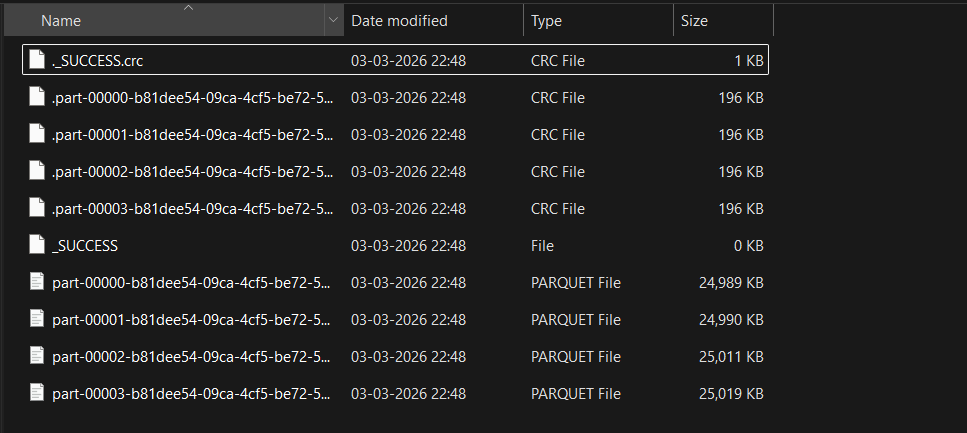

q3

In [5]:
from pyspark.sql.functions import col, to_date

df_filtered = df.filter(
    to_date(col("tpep_pickup_datetime")) == "2025-11-15"
)

df_filtered.count()

162604

q4

In [7]:
from pyspark.sql.functions import unix_timestamp, col, max as spark_max

df_with_duration = df.withColumn(
    "trip_duration_hours",
    (unix_timestamp(col("tpep_dropoff_datetime")) - 
     unix_timestamp(col("tpep_pickup_datetime"))) / 3600
)

df_with_duration.select(
    spark_max("trip_duration_hours")
).show()

+------------------------+
|max(trip_duration_hours)|
+------------------------+
|       90.64666666666666|
+------------------------+



q5

In [8]:
spark.sparkContext.uiWebUrl

'http://host.docker.internal:4040'

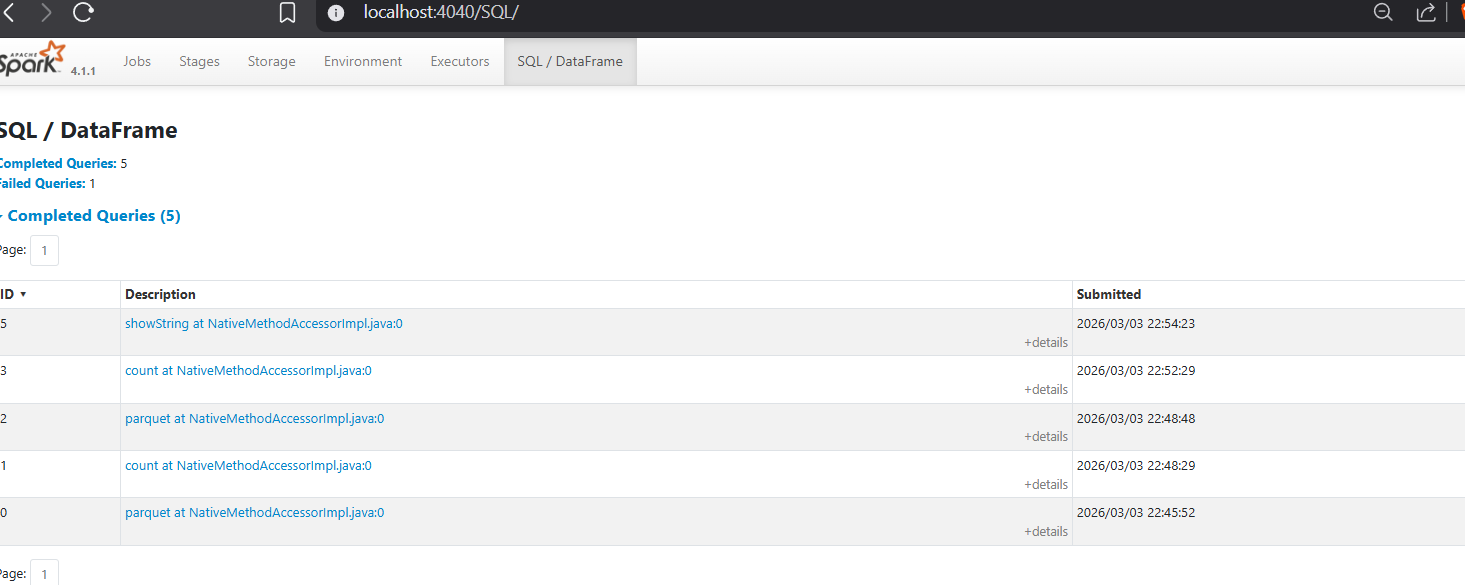

q6

In [9]:
df = spark.read.parquet("yellow_tripdata_2025-11.parquet")
zones = spark.read.option("header", True).csv("taxi_zone_lookup.csv")

In [10]:
from pyspark.sql.functions import count

df_joined = df.join(
    zones,
    df.PULocationID == zones.LocationID,
    "inner"
)

least_zone = (
    df_joined
    .groupBy("Zone")
    .agg(count("*").alias("trip_count"))
    .orderBy("trip_count")
)

least_zone.show(5)

+--------------------+----------+
|                Zone|trip_count|
+--------------------+----------+
|Governor's Island...|         1|
|Eltingville/Annad...|         1|
|       Arden Heights|         1|
|       Port Richmond|         3|
|       Rikers Island|         4|
+--------------------+----------+
only showing top 5 rows
